# RFSI versus non-spatial Random Forest for Meuse zinc

## A leakage-safe 5-fold cross-validation workflow (in Python)
#### *by Olha Kachalova*

### Research questions:
1. Is zinc prediction more accurate when Random Forest Spatial Interpolation (RFSI) is used instead of a Random Forest (RF) that ignores sample locations?
2. Does adding flood-related and soil covariates change the result?

### What this workflow does:

1. comparing RF and RFSI on exactly the same five folds;
2. repeating the comparison under three matched covariate scenarios;
3. constructing nearest-observation features separately inside every fold, preventing target leakage;
4. reporting RMSE, MAE, $R^2$, mean error and Lin's concordance correlation coefficient (CCC);
5. evaluating the *paired* difference between methods, rather than comparing two unrelated scores;
6. fitting both methods to all observations and mapping zinc over `meuse.grid`.
7. Optional sensitivity analyses:
   - to the number of neighbours;
   - repeated 5-fold;
   - log-transformation of zink values


### Main references

- Sekulić, A. et al. (2020), [Random Forest Spatial Interpolation](https://doi.org/10.3390/rs12101687), *Remote Sensing*, 12, 1687.
- OpenGeoHub, [Spatial interpolation using ML and geographical distances to neighbours](https://opengeohub.github.io/spatial-prediction-eml/spatial-interpolation-using-ensemble-ml.html#spatial-interpolation-using-ml-and-geographical-distances-to-neighbors).
- OpenGeoHub, [Spatial and spatiotemporal interpolation using Ensemble Machine Learning](https://opengeohub.github.io/spatial-prediction-eml/).
- `sp` documentation for the [Meuse observations](https://edzer.github.io/sp/reference/meuse.html) and [Meuse prediction grid](https://edzer.github.io/sp/reference/meuse.grid.html).


## 1. Some theory

Let $z(s)$ be zinc at location $s$, and let $c(s)$ contain environmental covariates.

### RF that ignores locations

The non-spatial model is

$$\hat z(s_0)=f_{RF}\{c(s_0)\}.$$

Coordinates `x` and `y`, distances to sample points, and neighbouring zinc observations are deliberately excluded. The model can still reproduce spatial patterns *indirectly* when environmental covariates themselves are spatially structured. Here, `dist` means distance to the Meuse river; it is an environmental covariate, not the location coordinates.

### RFSI

RFSI augments the same environmental covariates with the values and distances of the $k$ nearest observed samples:

$$\hat z(s_0)=f_{RF}\{c(s_0),z(s_{(1)}),\ldots,z(s_{(k)}),d_{(1)},\ldots,d_{(k)}\}.$$

The neighbours are ordered by distance from the prediction location. RFSI is therefore similar in spirit to kriging or IDW because nearby measured responses directly inform a prediction, but RF learns a nonlinear, non-parametric combination instead of imposing a variogram and a linear weighted average.


## 2. Setting Up the Software

Python libraries needed: `numpy` `pandas` `scipy` `scikit-learn` `matplotlib` `seaborn` `pyreadr`

In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

from pathlib import Path
from urllib.request import urlretrieve
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadr

from scipy.stats import skew
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

## 3. Meuse dataset: owerview, data integrity checks and explanatory analysis

The observation table has 155 topsoil samples. Zinc is measured in mg kg$^{-1}$ soil. Coordinates use the Dutch RD New projected coordinate system (EPSG:28992), so Euclidean neighbour distances are in metres, which is necessary.

In [2]:
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

BASE_URL = "https://raw.githubusercontent.com/edzer/sp/master/data"


def load_rda(name):
    path = DATA_DIR / f"{name}.rda"
    if not path.exists():
        print(f"Downloading {name}.rda ...")
        urlretrieve(f"{BASE_URL}/{name}.rda", path)
    result = pyreadr.read_r(str(path))
    return result[name].reset_index(drop=True)


meuse = load_rda("meuse")
grid = load_rda("meuse.grid")

# Force categorical variables to ordinary strings. This avoids accidentally
# treating class codes as continuous quantities.
for col in ["ffreq", "soil", "lime", "landuse"]:
    if col in meuse:
        meuse[col] = meuse[col].astype(object).where(meuse[col].notna(), "Missing").astype(str)
for col in ["ffreq", "soil"]:
    grid[col] = grid[col].astype(object).where(grid[col].notna(), "Missing").astype(str)

print("Observations:", meuse.shape)
print("Prediction grid:", grid.shape)
display(meuse.head())

Observations: (155, 14)
Prediction grid: (3103, 7)


,x,y,cadmium,copper,lead,zinc,elev,dist,om,ffreq,soil,lime,landuse,dist.m
0,181072.0,333611.0,11.7,85.0,299.0,1022.0,7.909,0.001358,13.6,1,1,1,Ah,50.0
1,181025.0,333558.0,8.6,81.0,277.0,1141.0,6.983,0.012224,14.0,1,1,1,Ah,30.0
2,181165.0,333537.0,6.5,68.0,199.0,640.0,7.800,0.103029,13.0,1,1,1,Ah,150.0
3,181298.0,333484.0,2.6,81.0,116.0,257.0,7.655,0.190094,8.0,1,2,0,Ga,270.0
4,181307.0,333330.0,2.8,48.0,117.0,269.0,7.480,0.277090,8.7,1,2,0,Ah,380.0


### Data integrity checks

RFSI training features exclude each sample from its own neighbour list. This is easiest and safest when sample coordinates are unique. The checks below fail early if the target or coordinates are missing, the CRS-like coordinate scale is implausible, or duplicated locations occur.


In [3]:
required_obs = {"x", "y", "zinc", "dist", "ffreq", "soil"}
required_grid = {"x", "y", "dist", "ffreq", "soil"}

assert required_obs.issubset(meuse.columns)
assert required_grid.issubset(grid.columns)
assert meuse[["x", "y", "zinc"]].notna().all().all()
assert not meuse.duplicated(["x", "y"]).any(), "Duplicate coordinates need explicit handling."
assert meuse["x"].median() > 100_000, "Coordinates do not look like projected RD New metres."
assert len(meuse) == 155

print(meuse["zinc"].describe())
print("Zinc skewness:", round(skew(meuse["zinc"], bias=False), 3))
print("Flood-frequency counts:\n", meuse["ffreq"].value_counts().sort_index())

count     155.000000
mean      469.716129
std       367.073788
min       113.000000
25%       198.000000
50%       326.000000
75%       674.500000
max      1839.000000
Name: zinc, dtype: float64
Zinc skewness: 1.486
Flood-frequency counts:
 ffreq
1    84
2    48
3    23
Name: count, dtype: int64


### Exploratory analysis

Zinc is strongly right-skewed, and high concentrations occur mainly near the river. This matters because RMSE heavily penalizes large errors at high-zinc observations, while MAE describes typical absolute error more robustly. We therefore report both. **Raw zinc is considered the primary target** so results are directly interpretable in mg kg$^{-1}$; a **log-target sensitivity analysis** is offered later in addons.

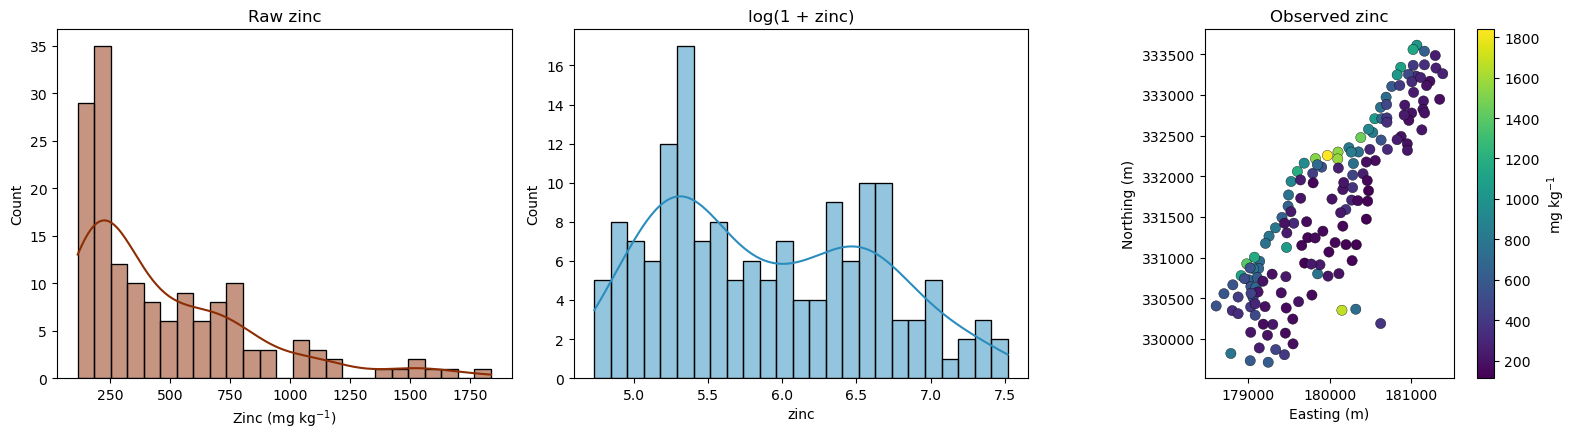

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(meuse["zinc"], bins=25, kde=True, ax=axes[0], color="#8c2d04")
axes[0].set_title("Raw zinc")
axes[0].set_xlabel("Zinc (mg kg$^{-1}$)")

sns.histplot(np.log1p(meuse["zinc"]), bins=25, kde=True, ax=axes[1], color="#2b8cbe")
axes[1].set_title("log(1 + zinc)")

sc = axes[2].scatter(
    meuse["x"], meuse["y"], c=meuse["zinc"], s=55,
    cmap="viridis", edgecolor="black", linewidth=0.25
)
axes[2].set_title("Observed zinc")
axes[2].set_aspect("equal")
axes[2].set_xlabel("Easting (m)")
axes[2].set_ylabel("Northing (m)")
fig.colorbar(sc, ax=axes[2], label="mg kg$^{-1}$")

plt.tight_layout()
plt.show()

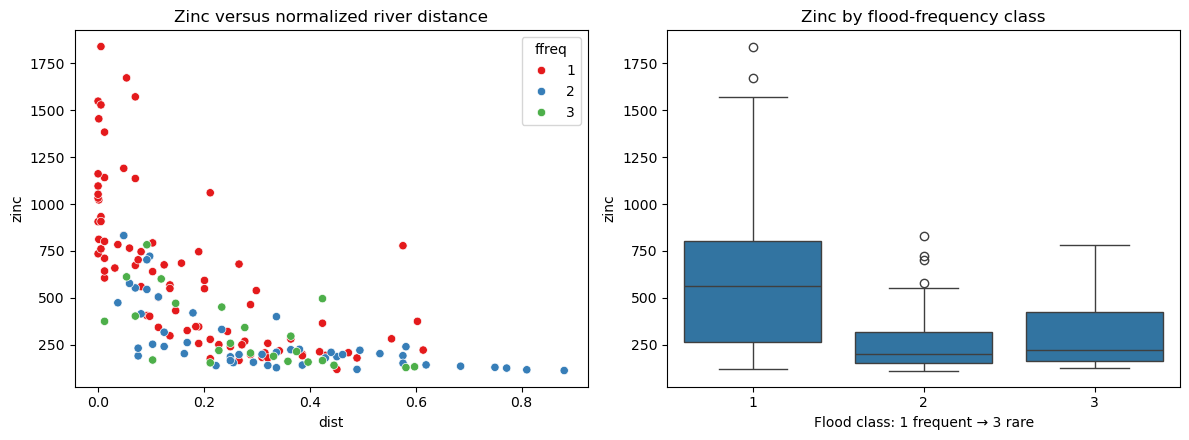

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=meuse, x="dist", y="zinc", hue="ffreq", palette="Set1", ax=axes[0])
axes[0].set_title("Zinc versus normalized river distance")

sns.boxplot(data=meuse, x="ffreq", y="zinc", order=["1", "2", "3"], ax=axes[1])
axes[1].set_title("Zinc by flood-frequency class")
axes[1].set_xlabel("Flood class: 1 frequent → 3 rare")
plt.tight_layout()
plt.show()

## 4. Experimental design

We use a factorial comparison so that the RFSI effect is not confused with the covariate effect.

| Covariate scenario | Environmental predictors available at points and grid | Purpose |
|---|---|---|
| `distance_only` | `dist` | Minimal environmental baseline: normalized distance to the river |
| `distance_flood` | `dist`, `ffreq` | Adds inundation frequency |
| `distance_flood_soil` | `dist`, `ffreq`, `soil` | Adds inundation frequency and mapped soil type |

Within each scenario:

- **RF** uses only the listed environmental predictors.
- **RFSI** uses the same predictors plus $k$ nearest zinc observations and their Euclidean distances.

`ffreq` is categorical: class 1 = flooding once in two years, class 2 = once in ten years, and class 3 = once in 50 years. It is one-hot encoded rather than treated as a linear numeric scale. `soil` is also categorical. Comparing distance_ffreq (dist + ffreq) with distance_only (dist) isolates the added contribution of flooding frequency. Comparing distance_ffreq_soil (dist + ffreq + soil) with distance_ffreq (dist + ffreq) isolates the additional contribution of soil type.

**Limitations:**
According to the dataset documentation, the origin of the gridded flood-frequency map is not known and the gridded soil classes should be treated cautiously.

## 5. Accuracy measures

- **RMSE:** same units as zinc and sensitive to large errors; the primary metric in the RFSI paper.
- **MAE:** typical absolute error and less dominated by extremes.
- **$R^2$:** proportional reduction in squared error relative to predicting the overall mean. It can be negative under CV.
- **Mean error (ME):** signed bias; values near zero are desirable.
- **CCC:** agreement with the 1:1 line; unlike correlation alone, it penalizes both scale and mean bias.

Scores are computed from all out-of-fold predictions pooled together. Fold scores are retained for diagnostics, but simply averaging five fold $R^2$ values is avoided because folds have different target means and variances.

In [6]:
def concordance_correlation_coefficient(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    cov = np.cov(y_true, y_pred, ddof=1)[0, 1]
    denominator = (
        np.var(y_true, ddof=1)
        + np.var(y_pred, ddof=1)
        + (np.mean(y_true) - np.mean(y_pred)) ** 2
    )
    return 2 * cov / denominator


def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "ME": np.mean(y_pred - y_true),
        "CCC": concordance_correlation_coefficient(y_true, y_pred),
    }

## 6. Constructing leakage-safe RFSI predictors

This is the critical step.

For an **outer training sample**, find neighbours only among the outer training samples and remove the sample itself. For an **outer validation sample**, find neighbours only among the outer training samples. The held-out zinc values must never appear in `obs_1`, ..., `obs_k`.

An unsafe workflow would construct nearest-observation predictors once from all 155 samples and then call `cross_val_score`. A validation sample would then often receive its own zinc or another validation zinc as a predictor. The resulting accuracy could look excellent while being invalid.

In [7]:
def nearest_observation_features(
    reference_xy,
    reference_z,
    query_xy,
    k=10,
    exclude_self=False,
):
    
    reference_xy = np.asarray(reference_xy, dtype=float)
    reference_z = np.asarray(reference_z, dtype=float)
    query_xy = np.asarray(query_xy, dtype=float)

    extra = 1 if exclude_self else 0
    if k + extra > len(reference_xy):
        raise ValueError("k is too large for the available reference samples.")

    search = NearestNeighbors(n_neighbors=k + extra, metric="euclidean")
    search.fit(reference_xy)
    distances, indices = search.kneighbors(query_xy)

    if exclude_self:
        # Coordinates were checked as unique; the zero-distance first neighbour
        # is therefore the row itself and must be removed.
        if not np.allclose(distances[:, 0], 0):
            raise ValueError("Self-neighbour was not found at distance zero.")
        distances = distances[:, 1:]
        indices = indices[:, 1:]

    data = {}
    for j in range(k):
        data[f"obs_{j + 1}"] = reference_z[indices[:, j]]
    for j in range(k):
        data[f"nn_distance_{j + 1}"] = distances[:, j]
    return pd.DataFrame(data)

In [8]:
# Sanity check on the complete sample set. The closest non-self distance must
# be positive, and obs_1 is another sample's zinc rather than the target itself.
demo_nn = nearest_observation_features(
    meuse[["x", "y"]], meuse["zinc"], meuse[["x", "y"]],
    k=10, exclude_self=True
)
assert (demo_nn.filter(like="nn_distance_") > 0).all().all()
display(pd.concat([meuse[["zinc"]].head(), demo_nn.head()], axis=1))

,zinc,obs_1,obs_2,obs_3,obs_4,obs_5,obs_6,obs_7,obs_8,obs_9,...,nn_distance_1,nn_distance_2,nn_distance_3,nn_distance_4,nn_distance_5,nn_distance_6,nn_distance_7,nn_distance_8,nn_distance_9,nn_distance_10
0,1022.0,1141.0,640.0,406.0,346.0,257.0,1096.0,269.0,504.0,347.0,...,70.837843,118.848643,252.049598,258.321505,259.239272,336.434243,366.314073,373.483601,380.189426,399.656102
1,1141.0,1022.0,640.0,406.0,346.0,1096.0,257.0,504.0,347.0,279.0,...,70.837843,141.566239,195.010256,234.401365,266.011278,282.851551,311.081983,328.867755,356.349547,362.640318
2,640.0,1022.0,1141.0,257.0,346.0,406.0,269.0,347.0,279.0,504.0,...,118.848643,141.566239,143.171226,167.000000,222.081066,251.023903,323.513524,326.401593,345.891602,351.973010
3,257.0,640.0,269.0,346.0,281.0,1022.0,1141.0,406.0,183.0,279.0,...,143.171226,154.262763,175.171345,242.156974,259.239272,282.851551,296.786118,322.818835,324.499615,347.351407
4,269.0,281.0,346.0,257.0,183.0,279.0,189.0,640.0,347.0,406.0,...,108.577162,147.526269,154.262763,178.518907,221.758878,244.296950,251.023903,266.101484,281.937936,340.847473


## 7. Model-building helpers

The same RF settings are used in both methods to isolate the effect of adding RFSI predictors. `max_features="sqrt"` scales the number of candidate variables with feature count, while `min_samples_leaf=2` slightly regularizes the very small dataset. These are fixed *before* looking at outer-fold results; therefore the primary comparison does not require nested tuning.

Categorical encoders and imputers are fitted inside each training fold. Coordinates are used only by the RFSI neighbour search, never as ordinary RF predictors.

In [9]:
RANDOM_STATE = 2026
N_SPLITS = 5
K_NEIGHBORS = 10       # same k as the OpenGeoHub Meuse tutorial, is a subject to explore
N_TREES = 600
N_JOBS = -1
CATEGORICAL_COLUMNS = {"ffreq", "soil", "lime", "landuse"}


def make_rf_pipeline(feature_columns, random_state=RANDOM_STATE, n_trees=N_TREES):
    categorical = [c for c in feature_columns if c in CATEGORICAL_COLUMNS]
    numeric = [c for c in feature_columns if c not in CATEGORICAL_COLUMNS]

    transformers = []
    if numeric:
        transformers.append((
            "numeric",
            SimpleImputer(strategy="median"),
            numeric,
        ))
    if categorical:
        transformers.append((
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
            ]),
            categorical,
        ))

    preprocessing = ColumnTransformer(transformers, remainder="drop")
    forest = RandomForestRegressor(
        n_estimators=n_trees,
        max_features="sqrt",
        min_samples_leaf=2,
        bootstrap=True,
        random_state=random_state,
        n_jobs=N_JOBS,
    )
    return Pipeline([("preprocess", preprocessing), ("rf", forest)])


def fold_feature_tables(train, test, environmental_columns, method, k):
    '''Build train/test predictors using only the fold's training reference set.'''
    X_train = train[environmental_columns].reset_index(drop=True).copy()
    X_test = test[environmental_columns].reset_index(drop=True).copy()

    if method == "RFSI":
        train_nn = nearest_observation_features(
            train[["x", "y"]], train["zinc"], train[["x", "y"]],
            k=k, exclude_self=True,
        )
        test_nn = nearest_observation_features(
            train[["x", "y"]], train["zinc"], test[["x", "y"]],
            k=k, exclude_self=False,
        )
        X_train = pd.concat([X_train, train_nn], axis=1)
        X_test = pd.concat([X_test, test_nn], axis=1)
    elif method != "RF":
        raise ValueError("method must be 'RF' or 'RFSI'")

    return X_train, X_test

## 8. Primary shuffled 5-fold cross-validation

The primary resampling design is shuffled 5-fold CV. Because every Meuse sample has a unique location, holding out a row also holds out that location. It estimates **interpolation among a remaining, spatially interspersed sample network**. A spatially clustered 5-fold sensitivity test is included later; it asks the harder question of prediction into withheld geographic subregions and should not be interpreted as the same estimand.

Both methods and both covariate scenarios use the **same folds**, making all comparisons paired. Within every fold, the reference network available to RFSI contains only 80% of the observations. This honestly reproduces the information available when predicting a withheld location.

No target transformation is used in the primary analysis.

In [10]:
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

def make_random_folds(data, random_state=RANDOM_STATE):
    splitter = KFold(n_splits=N_SPLITS, shuffle=True, random_state=random_state)
    return list(splitter.split(data))


def cross_validate_method(
    data,
    folds,
    environmental_columns,
    method,
    k=K_NEIGHBORS,
    n_trees=N_TREES,
):
    oof = np.full(len(data), np.nan)
    fold_id = np.full(len(data), -1, dtype=int)

    for fold_number, (train_index, test_index) in enumerate(folds, start=1):
        train = data.iloc[train_index].reset_index(drop=True)
        test = data.iloc[test_index].reset_index(drop=True)

        X_train, X_test = fold_feature_tables(
            train, test, environmental_columns, method, k
        )
        model = make_rf_pipeline(
            X_train.columns.tolist(),
            random_state=RANDOM_STATE + fold_number,
            n_trees=n_trees,
        )
        model.fit(X_train, train["zinc"])
        oof[test_index] = model.predict(X_test)
        fold_id[test_index] = fold_number

    assert np.isfinite(oof).all()
    return pd.DataFrame({
        "observed": data["zinc"].to_numpy(),
        "predicted": oof,
        "fold": fold_id,
        "x": data["x"].to_numpy(),
        "y": data["y"].to_numpy(),
    })


SCENARIOS = {
    "distance_only": ["dist"],
    "distance_flood": ["dist", "ffreq"],
    "distance_flood_soil": ["dist", "ffreq", "soil"],
}

primary_folds = make_random_folds(meuse)
predictions = {}

for scenario, columns in SCENARIOS.items():
    for method in ["RF", "RFSI"]:
        print(f"Running {scenario} / {method}")
        predictions[(scenario, method)] = cross_validate_method(
            meuse, primary_folds, columns, method, k=K_NEIGHBORS
        )

Running distance_only / RF
Running distance_only / RFSI
Running distance_flood / RF
Running distance_flood / RFSI
Running distance_flood_soil / RF
Running distance_flood_soil / RFSI


## 9. Overall and fold-level accuracy

Interpretation notes:

Lower RMSE/MAE and absolute ME, but higher $R^2$/CCC - better. A negative `delta_RMSE` means RFSI is more accurate than RF.
It's better not to call a tiny numerical difference scientifically important merely because it has the preferred sign. We should consider its size relative to RF RMSE, its stability across folds and seeds, and its uncertainty.

In [11]:
scenario_order = ["distance_only", "distance_flood", "distance_flood_soil"]

overall_rows = []
fold_rows = []

for (scenario, method), result in predictions.items():
    overall_rows.append({
        "scenario": scenario,
        "method": method,
        **regression_metrics(result["observed"], result["predicted"]),
    })
    for fold_number, part in result.groupby("fold"):
        fold_rows.append({
            "scenario": scenario,
            "method": method,
            "fold": fold_number,
            **regression_metrics(part["observed"], part["predicted"]),
        })

overall_scores = pd.DataFrame(overall_rows)
overall_scores["scenario"] = pd.Categorical(
    overall_scores["scenario"], categories=scenario_order, ordered=True
)
overall_scores = overall_scores.sort_values(["scenario", "method"])

fold_scores = pd.DataFrame(fold_rows)
fold_scores["scenario"] = pd.Categorical(
    fold_scores["scenario"], categories=scenario_order, ordered=True
)
fold_scores = fold_scores.sort_values(["scenario", "fold", "method"])

display(overall_scores.round(3))

wide = overall_scores.pivot(index="scenario", columns="method")
wide = wide.reindex(scenario_order)

method_effect = pd.DataFrame(index=wide.index)
method_effect["delta_RMSE"] = wide["RMSE"]["RFSI"] - wide["RMSE"]["RF"]
method_effect["RMSE_change_percent"] = 100 * method_effect["delta_RMSE"] / wide["RMSE"]["RF"]
method_effect["delta_MAE"] = wide["MAE"]["RFSI"] - wide["MAE"]["RF"]
method_effect["delta_R2"] = wide["R2"]["RFSI"] - wide["R2"]["RF"]
method_effect["delta_CCC"] = wide["CCC"]["RFSI"] - wide["CCC"]["RF"]

display(method_effect.round(3))

,scenario,method,RMSE,MAE,R2,ME,CCC
0,distance_only,RF,261.004,183.227,0.491,-5.955,0.697
1,distance_only,RFSI,235.745,158.249,0.585,5.317,0.701
2,distance_flood,RF,232.226,162.545,0.597,-5.739,0.764
3,distance_flood,RFSI,224.418,151.783,0.624,6.862,0.731
4,distance_flood_soil,RF,221.923,156.824,0.632,-2.080,0.779
5,distance_flood_soil,RFSI,221.002,149.508,0.635,5.556,0.745


,delta_RMSE,RMSE_change_percent,delta_MAE,delta_R2,delta_CCC
scenario,,,,,
distance_only,-25.259,-9.678,-24.978,0.094,0.004
distance_flood,-7.808,-3.362,-10.762,0.027,-0.033
distance_flood_soil,-0.921,-0.415,-7.316,0.003,-0.035


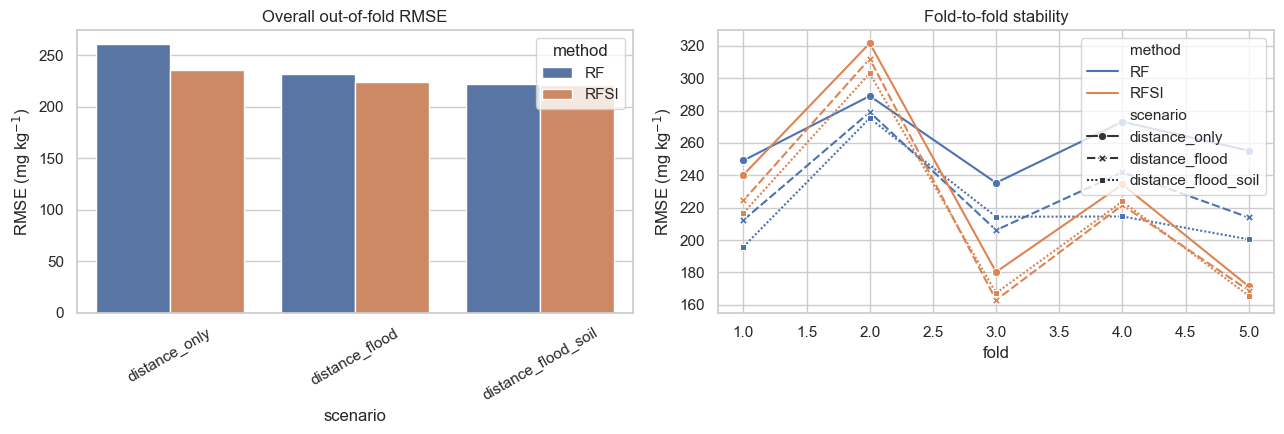

In [12]:
scenario_order = ["distance_only", "distance_flood", "distance_flood_soil"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.barplot(
    data=overall_scores, x="scenario", y="RMSE", hue="method",
    order=scenario_order, ax=axes[0]
)
axes[0].set_title("Overall out-of-fold RMSE")
axes[0].set_ylabel("RMSE (mg kg$^{-1}$)")
axes[0].tick_params(axis="x", rotation=30)

sns.lineplot(
    data=fold_scores, x="fold", y="RMSE", hue="method",
    style="scenario", style_order=scenario_order,
    markers=True, dashes=True, ax=axes[1]
)
axes[1].set_title("Fold-to-fold stability")
axes[1].set_ylabel("RMSE (mg kg$^{-1}$)")

plt.tight_layout()
plt.show()

### Residual maps

Spatial clustering of residuals indicates structure not captured by the model. Similar residual clusters in RF and RFSI may reflect missing environmental processes, outliers, or a mismatch between sampling support and raster support. Remember that every point shown below is an out-of-fold prediction.

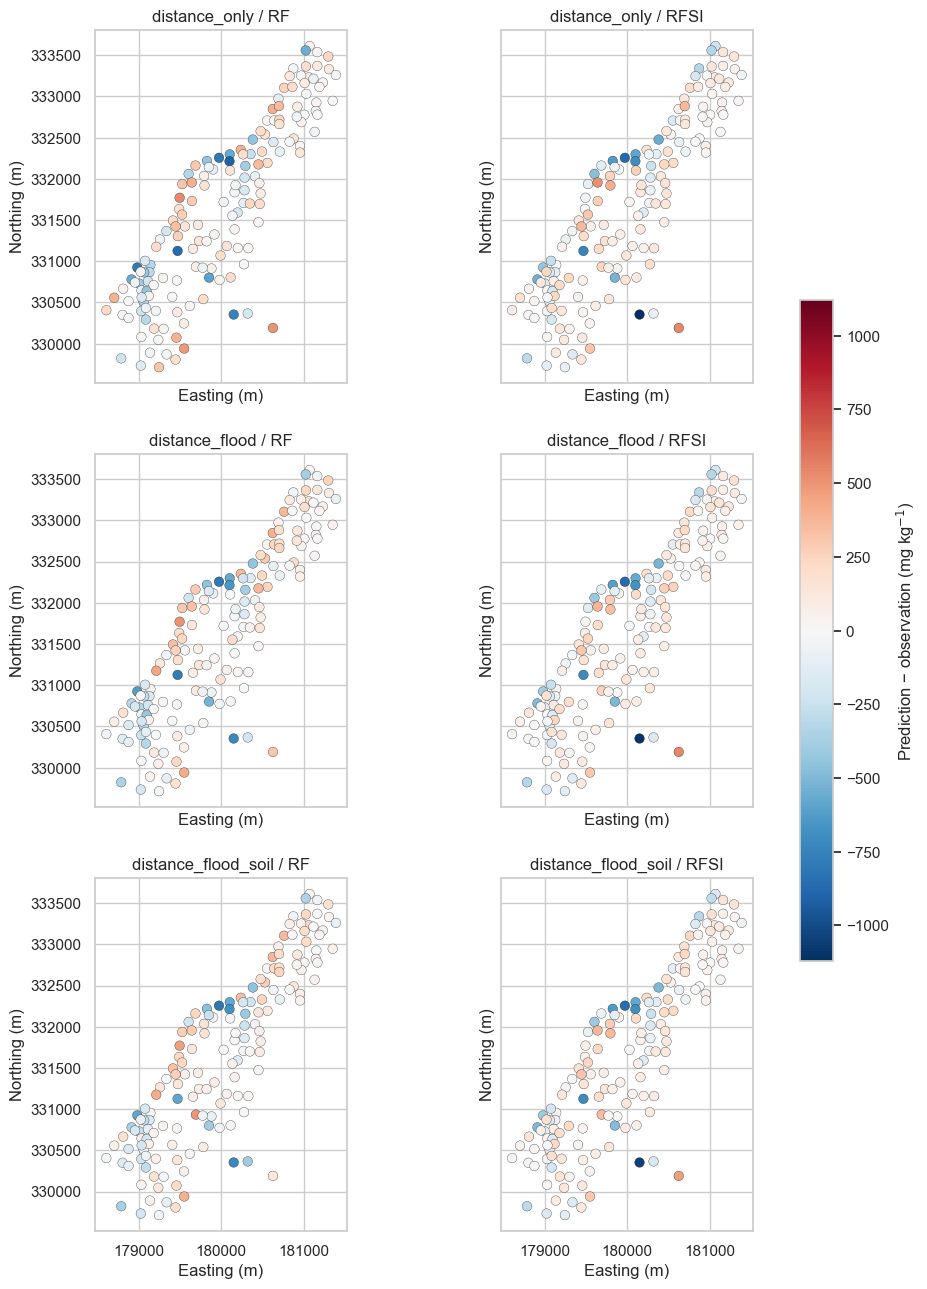

In [13]:
n_scenarios = len(SCENARIOS)
fig, axes = plt.subplots(
    n_scenarios, 2, figsize=(12, 5.2 * n_scenarios),
    sharex=True, sharey=True, squeeze=False
)
residual_limit = max(
    np.abs(v["predicted"] - v["observed"]).max() for v in predictions.values()
)

for row, scenario in enumerate(SCENARIOS):
    for column, method in enumerate(["RF", "RFSI"]):
        ax = axes[row, column]
        result = predictions[(scenario, method)]
        residual = result["predicted"] - result["observed"]
        sc = ax.scatter(
            result["x"], result["y"], c=residual, cmap="RdBu_r",
            vmin=-residual_limit, vmax=residual_limit, s=48,
            edgecolor="black", linewidth=0.2
        )
        ax.set_title(f"{scenario} / {method}")
        ax.set_aspect("equal")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")

fig.colorbar(
    sc, ax=axes.ravel().tolist(), shrink=0.55,
    label="Prediction − observation (mg kg$^{-1}$)"
)
plt.show()

## 10. Paired uncertainty assessment with a spatial block bootstrap

The same observations and folds are used for RF and RFSI, so uncertainty should be evaluated on their **paired difference**. A naive independent-samples test would discard this pairing. A naive point bootstrap would also treat spatially correlated errors as independent.

The approximation below partitions observations into ten spatial clusters, resamples whole clusters, and recalculates $\Delta RMSE = RMSE_{RFSI}-RMSE_{RF}$. A 95% interval entirely below zero supports an RFSI improvement for this CV design. An interval crossing zero means the data do not clearly distinguish the methods. This is an uncertainty/sensitivity analysis, not a definitive universal hypothesis test: the sample is small, block definitions are subjective, and OOF predictions depend on the chosen folds.

In [14]:
def spatial_block_bootstrap_delta_rmse(
    observed, pred_rf, pred_rfsi, xy,
    n_blocks=10, n_boot=5000, random_state=RANDOM_STATE,
):
    xy = np.asarray(xy, dtype=float)
    # Standardization prevents the larger coordinate range from dominating clustering.
    xy_scaled = (xy - xy.mean(axis=0)) / xy.std(axis=0)
    blocks = KMeans(n_clusters=n_blocks, n_init=20, random_state=random_state).fit_predict(xy_scaled)
    block_labels = np.unique(blocks)
    rng = np.random.default_rng(random_state)
    deltas = np.empty(n_boot)

    for b in range(n_boot):
        sampled_blocks = rng.choice(block_labels, size=len(block_labels), replace=True)
        index = np.concatenate([np.flatnonzero(blocks == label) for label in sampled_blocks])
        rmse_rf = mean_squared_error(observed[index], pred_rf[index]) ** 0.5
        rmse_rfsi = mean_squared_error(observed[index], pred_rfsi[index]) ** 0.5
        deltas[b] = rmse_rfsi - rmse_rf
    return deltas, blocks


bootstrap_rows = []
bootstrap_distributions = {}

for scenario in SCENARIOS:
    rf = predictions[(scenario, "RF")]
    rfsi = predictions[(scenario, "RFSI")]
    deltas, spatial_blocks = spatial_block_bootstrap_delta_rmse(
        rf["observed"].to_numpy(),
        rf["predicted"].to_numpy(),
        rfsi["predicted"].to_numpy(),
        meuse[["x", "y"]].to_numpy(),
    )
    bootstrap_distributions[scenario] = deltas
    low, high = np.quantile(deltas, [0.025, 0.975])
    bootstrap_rows.append({
        "scenario": scenario,
        "observed_delta_RMSE": (
            regression_metrics(rfsi["observed"], rfsi["predicted"])["RMSE"]
            - regression_metrics(rf["observed"], rf["predicted"])["RMSE"]
        ),
        "bootstrap_CI_low": low,
        "bootstrap_CI_high": high,
        "P(delta_RMSE < 0)": np.mean(deltas < 0),
    })

bootstrap_summary = pd.DataFrame(bootstrap_rows)
display(bootstrap_summary.round(3))

C:\Users\kachalova\AppData\Local\anaconda3\envs\geo\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,scenario,observed_delta_RMSE,bootstrap_CI_low,bootstrap_CI_high,P(delta_RMSE < 0)
0,distance_only,-25.259,-62.974,21.103,0.871
1,distance_flood,-7.808,-43.715,35.529,0.657
2,distance_flood_soil,-0.921,-27.838,30.803,0.547


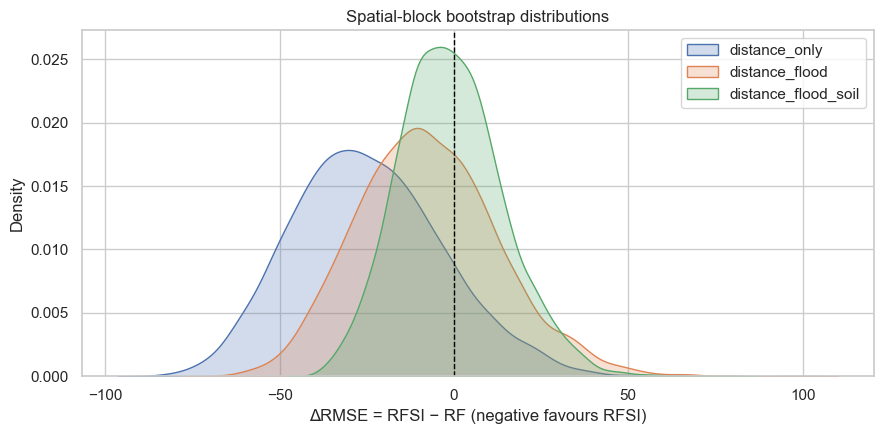

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for scenario, values in bootstrap_distributions.items():
    sns.kdeplot(values, fill=True, alpha=0.25, label=scenario, ax=ax)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("ΔRMSE = RFSI − RF (negative favours RFSI)")
ax.set_title("Spatial-block bootstrap distributions")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Fit the full models and create prediction maps

Cross-validation evaluates performance; final fitting creates maps. For the final RFSI model, training-sample features exclude self, while grid-cell features use all 155 observed samples as the reference network.

Only `dist`, `ffreq`, and `soil` are used because all three are available both at sample points and on `meuse.grid`. Point-only attributes such as organic matter, field elevation, lime, and land use cannot be used for wall-to-wall prediction unless equivalent raster layers are supplied for every grid cell.

In [16]:
def fit_full_and_predict_grid(
    data,
    prediction_grid,
    environmental_columns,
    method,
    k=K_NEIGHBORS,
):
    
    # Environmental predictors
    X_train = data[environmental_columns].reset_index(drop=True).copy()
    X_grid = prediction_grid[environmental_columns].reset_index(drop=True).copy()

    if method == "RFSI":

        # Neighbour predictors for training locations.
        # Each training sample is excluded from its own neighbour list.
        train_nn = nearest_observation_features(
            reference_xy=data[["x", "y"]],
            reference_z=data["zinc"],
            query_xy=data[["x", "y"]],
            k=k,
            exclude_self=True,
        )

        # Neighbour predictors for prediction-grid cells.
        # All observed Meuse samples can be used as reference observations.
        grid_nn = nearest_observation_features(
            reference_xy=data[["x", "y"]],
            reference_z=data["zinc"],
            query_xy=prediction_grid[["x", "y"]],
            k=k,
            exclude_self=False,
        )

        X_train = pd.concat(
            [X_train, train_nn.reset_index(drop=True)],
            axis=1,
        )

        X_grid = pd.concat(
            [X_grid, grid_nn.reset_index(drop=True)],
            axis=1,
        )

    elif method != "RF":
        raise ValueError("method must be 'RF' or 'RFSI'")

    model = make_rf_pipeline(
        feature_columns=X_train.columns.tolist(),
        random_state=RANDOM_STATE,
        n_trees=1000,
    )

    model.fit(X_train, data["zinc"])

    prediction = model.predict(X_grid)

    return model, prediction

In [17]:
METHODS = ["RF", "RFSI"]

final_models = {}
map_predictions = {}

for scenario, environmental_columns in SCENARIOS.items():

    final_models[scenario] = {}
    map_predictions[scenario] = {}

    for method in METHODS:

        print(
            f"Fitting {method} for {scenario}: "
            f"{environmental_columns}"
        )

        model, prediction = fit_full_and_predict_grid(
            data=meuse,
            prediction_grid=grid,
            environmental_columns=environmental_columns,
            method=method,
            k=K_NEIGHBORS,
        )

        final_models[scenario][method] = model
        map_predictions[scenario][method] = prediction

Fitting RF for distance_only: ['dist']
Fitting RFSI for distance_only: ['dist']
Fitting RF for distance_flood: ['dist', 'ffreq']
Fitting RFSI for distance_flood: ['dist', 'ffreq']
Fitting RF for distance_flood_soil: ['dist', 'ffreq', 'soil']
Fitting RFSI for distance_flood_soil: ['dist', 'ffreq', 'soil']


In [18]:
map_frame = grid[["x", "y"]].copy()

for scenario in SCENARIOS:

    rf_column = f"{scenario}_RF"
    rfsi_column = f"{scenario}_RFSI"
    difference_column = f"{scenario}_RFSI_minus_RF"

    map_frame[rf_column] = map_predictions[scenario]["RF"]
    map_frame[rfsi_column] = map_predictions[scenario]["RFSI"]

    map_frame[difference_column] = (
        map_frame[rfsi_column]
        - map_frame[rf_column]
    )

display(map_frame.head())

,x,y,distance_only_RF,distance_only_RFSI,distance_only_RFSI_minus_RF,distance_flood_RF,distance_flood_RFSI,distance_flood_RFSI_minus_RF,distance_flood_soil_RF,distance_flood_soil_RFSI,distance_flood_soil_RFSI_minus_RF
0,181180.0,333740.0,1075.000571,908.473221,-166.527350,1072.715099,937.282207,-135.432892,1056.720251,977.336213,-79.384038
1,181140.0,333700.0,1075.000571,910.323311,-164.677261,1072.715099,935.777648,-136.937451,1056.720251,955.104097,-101.616154
2,181180.0,333700.0,800.069573,886.694496,86.624923,879.468932,911.442259,31.973327,895.247779,952.526065,57.278286
3,181220.0,333700.0,942.553356,675.746420,-266.806936,1019.294719,737.605436,-281.689283,999.750992,767.221480,-232.529512
4,181100.0,333660.0,1075.000571,908.459090,-166.541481,1072.715099,918.918262,-153.796837,1056.720251,939.985972,-116.734279


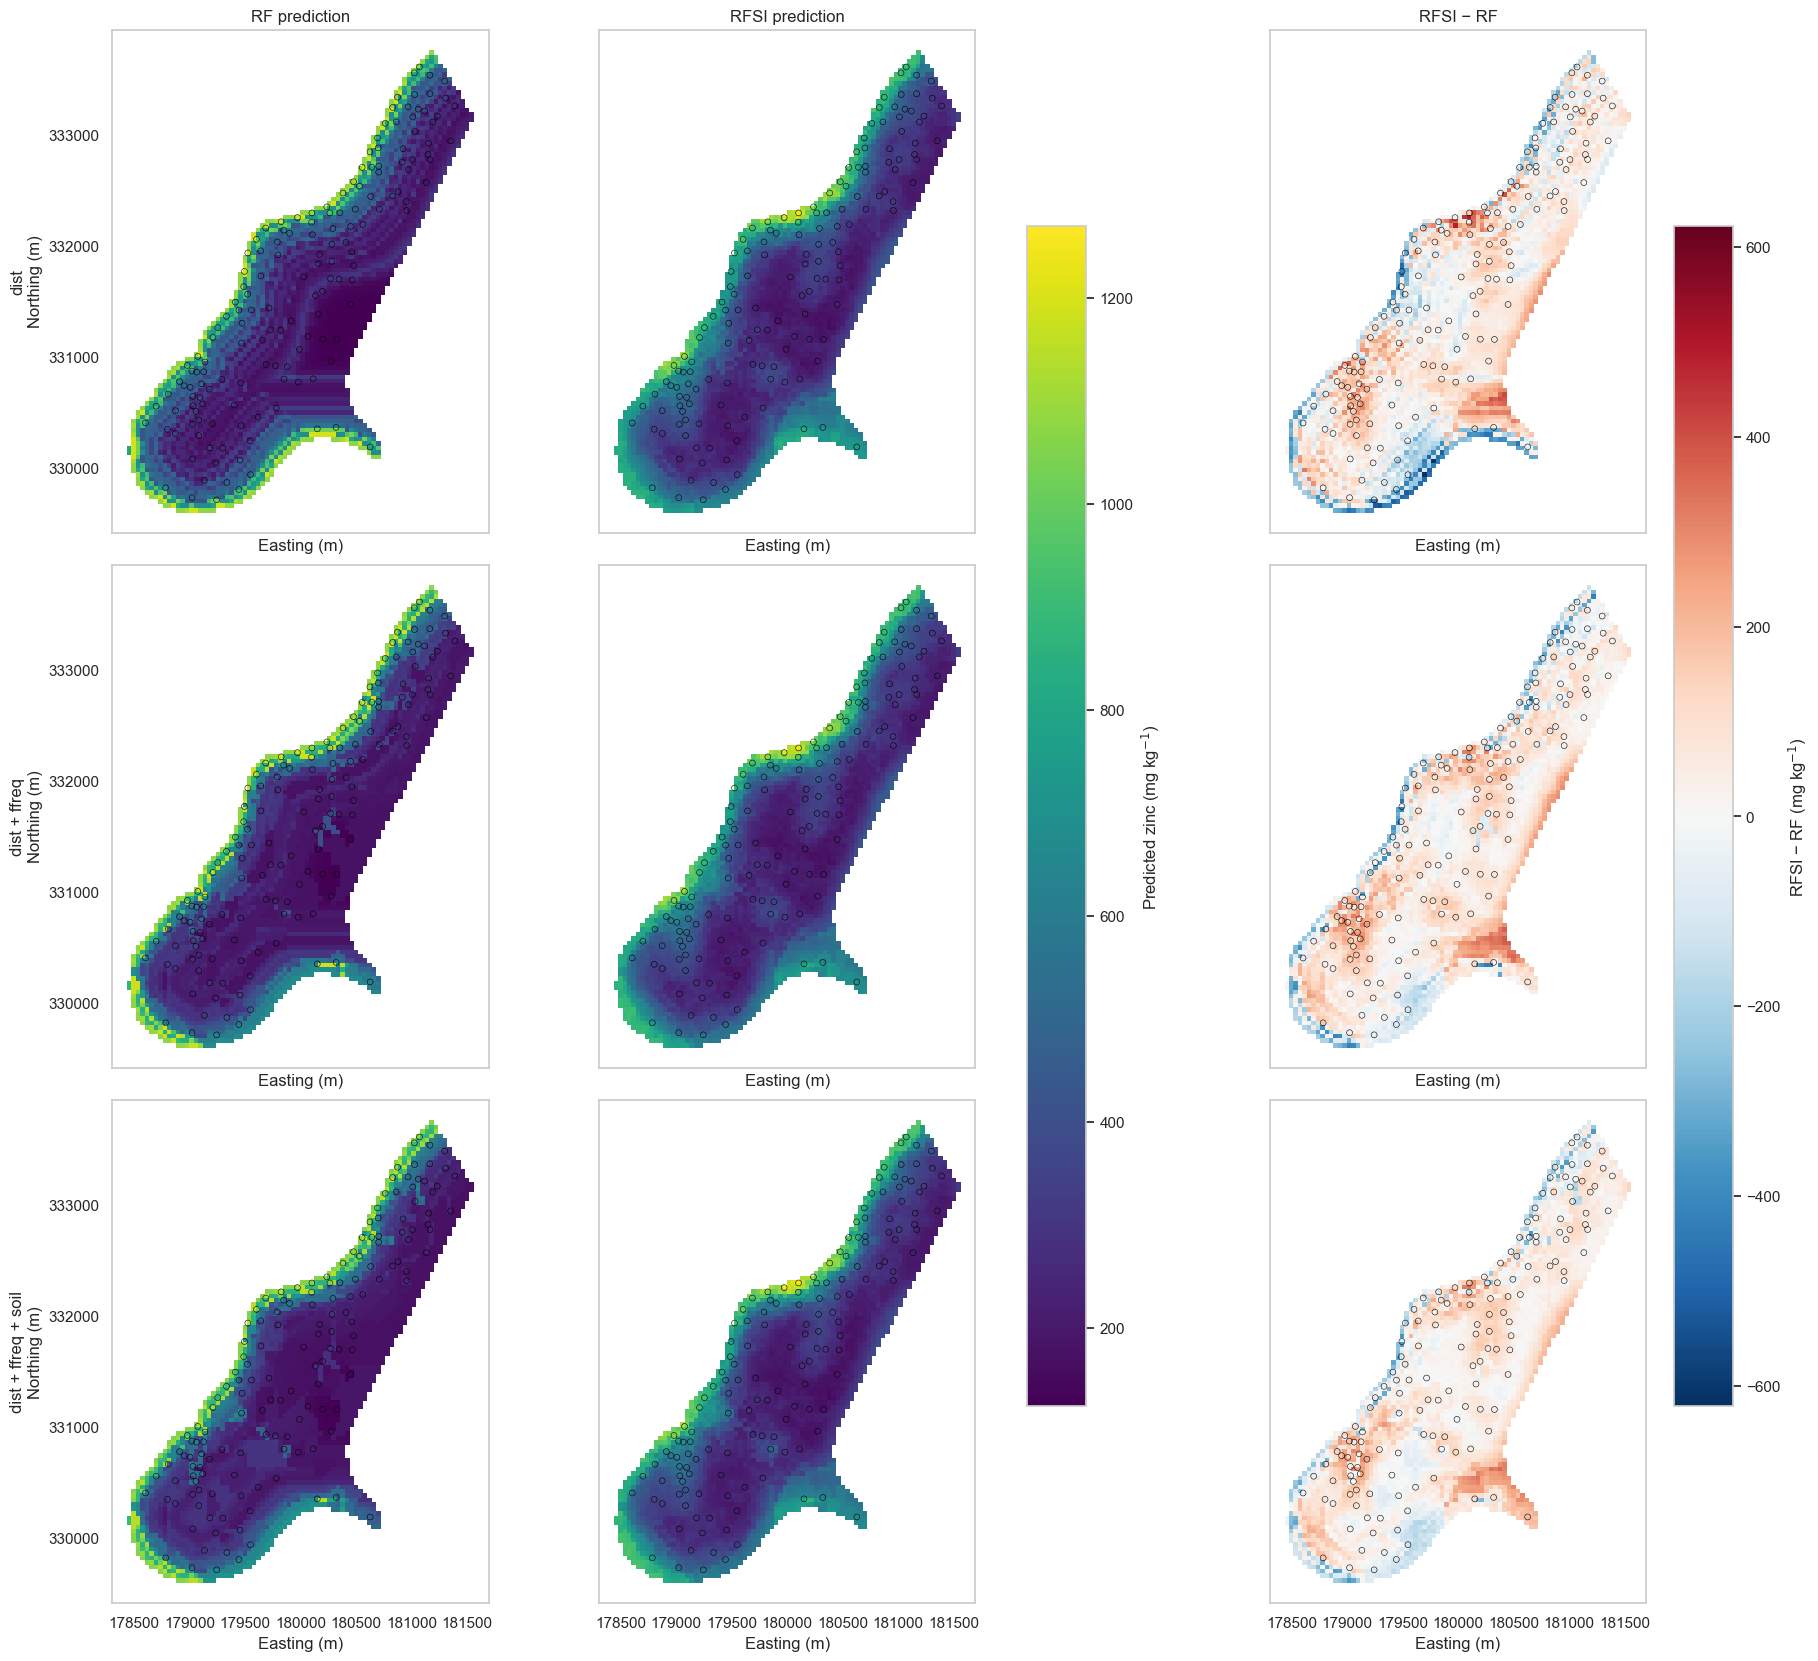

In [19]:
scenario_labels = {
    "distance_only": "dist",
    "distance_flood": "dist + ffreq",
    "distance_flood_soil": "dist + ffreq + soil",
}

n_scenarios = len(SCENARIOS)

fig, axes = plt.subplots(
    nrows=n_scenarios,
    ncols=3,
    figsize=(18, 5.5 * n_scenarios),
    sharex=True,
    sharey=True,
    layout="constrained",
    squeeze=False,
)

# Remove the grid lines created by seaborn's "whitegrid" style
for ax in axes.flat:
    ax.grid(False)
    ax.set_facecolor("white")


# ---------------------------------------------------------
# Common colour scale for all RF and RFSI predictions
# ---------------------------------------------------------

all_predictions = np.concatenate([
    map_predictions[scenario][method]
    for scenario in SCENARIOS
    for method in ["RF", "RFSI"]
])

prediction_min = all_predictions.min()
prediction_max = all_predictions.max()


# ---------------------------------------------------------
# Common symmetric scale for all RFSI − RF maps
# ---------------------------------------------------------

all_differences = np.concatenate([
    map_predictions[scenario]["RFSI"]
    - map_predictions[scenario]["RF"]
    for scenario in SCENARIOS
])

difference_limit = np.abs(all_differences).max()


# ---------------------------------------------------------
# Plot every scenario
# ---------------------------------------------------------

for row, scenario in enumerate(SCENARIOS):

    scenario_label = scenario_labels.get(scenario, scenario)

    rf_prediction = map_predictions[scenario]["RF"]
    rfsi_prediction = map_predictions[scenario]["RFSI"]
    difference = rfsi_prediction - rf_prediction

    # RF prediction
    sc_prediction = axes[row, 0].scatter(
        map_frame["x"],
        map_frame["y"],
        c=rf_prediction,
        cmap="viridis",
        vmin=prediction_min,
        vmax=prediction_max,
        marker="s",
        s=12,
        linewidths=0,
        edgecolors="none",
        antialiaseds=False,
        rasterized=True,
        zorder=1,
    )

    # RFSI prediction
    axes[row, 1].scatter(
        map_frame["x"],
        map_frame["y"],
        c=rfsi_prediction,
        cmap="viridis",
        vmin=prediction_min,
        vmax=prediction_max,
        marker="s",
        s=12,
        linewidths=0,
        edgecolors="none",
        antialiaseds=False,
        rasterized=True,
        zorder=1,
    )

    # RFSI − RF difference
    sc_difference = axes[row, 2].scatter(
        map_frame["x"],
        map_frame["y"],
        c=difference,
        cmap="RdBu_r",
        vmin=-difference_limit,
        vmax=difference_limit,
        marker="s",
        s=12,
        linewidths=0,
        edgecolors="none",
        antialiaseds=False,
        rasterized=True,
        zorder=1,
    )

    # Add sample locations
    for column in range(3):

        axes[row, column].scatter(
            meuse["x"],
            meuse["y"],
            facecolors="none",
            edgecolors="black",
            s=18,
            linewidths=0.4,
            antialiaseds=True,
            zorder=3,
        )

        axes[row, column].grid(False)
        axes[row, column].set_aspect("equal")
        axes[row, column].set_xlabel("Easting (m)")

    axes[row, 0].set_ylabel(
        f"{scenario_label}\nNorthing (m)"
    )


# ---------------------------------------------------------
# Column titles
# ---------------------------------------------------------

axes[0, 0].set_title("RF prediction")
axes[0, 1].set_title("RFSI prediction")
axes[0, 2].set_title("RFSI − RF")


# ---------------------------------------------------------
# Colour bars
# ---------------------------------------------------------

fig.colorbar(
    sc_prediction,
    ax=axes[:, :2].ravel().tolist(),
    shrink=0.75,
    label="Predicted zinc (mg kg$^{-1}$)",
)

fig.colorbar(
    sc_difference,
    ax=axes[:, 2].ravel().tolist(),
    shrink=0.75,
    label="RFSI − RF (mg kg$^{-1}$)",
)

plt.show()

# REPORT
## 1. Is there a difference in accuracy between RF and RFSI?

**RFSI produced lower RMSE and MAE than RF in all three scenarios**, but the magnitude of the improvement depended strongly on the environmental covariates included in the model.

| Scenario | RMSE improvement with RFSI | MAE improvement | Change in R² |
|----------|---------------------------:|----------------:|-------------:|
| Distance only | **25.259 mg/kg** (9.68%) | 24.978 mg/kg | +0.094 |
| Distance + flood frequency | **7.808 mg/kg** (3.36%) | 10.762 mg/kg | +0.027 |
| Distance + flood frequency + soil | **0.921 mg/kg** (0.42%) | 7.316 mg/kg | +0.003 |

With distance to the river as the only environmental predictor, RFSI clearly outperformed RF. After flood frequency was added, RFSI remained more accurate according to RMSE, MAE and R2, but its advantage became considerably smaller. With both flood frequency and soil type included, RF and RFSI had practically identical RMSE and R2.

CCC did not show a consistent RFSI advantage. RFSI reduced individual prediction errors but did not necessarily improve overall agreement in the mean and variance of predictions.

The mean errors were close to zero for all models. RF showed slight underprediction, whereas RFSI showed slight overprediction.

Therefore, **RFSI cannot be considered universally more accurate than RF**. It provided a meaningful advantage when environmental information was limited, but the advantage largely disappeared after relevant floodplain covariates were included.

## 2. Does adding flood frequency and soil type improve prediction?

**Yes.** Adding these covariates improved both methods, but the improvement was substantially larger for ordinary RF.

## Conclusion

These statistics demonstrate differences in predictive performance, but they do not by themselves establish statistical significance. A paired bootstrap or repeated cross-validation analysis is needed to determine whether the observed differences are greater than the uncertainty caused by the small dataset and the particular five-fold split.

# ADDITIONAL SENSITIVITY ANALYSES
## Sensitivity to the number of neighbours

The OpenGeoHub example uses 10 neighbours; the original RFSI paper used 25 in its case studies and treated neighbour count as a tunable parameter. Too small $k$ may make predictions unstable; too large $k$ may dilute local information and add correlated predictors.

The following is an **exploratory sensitivity analysis** using the same outer folds. Do not select the best $k$ here and then report its minimum RMSE as unbiased performance: that would tune on the evaluation folds. If formal tuning is required, $k$ must be chosen inside an inner CV loop nested within each outer fold.

k sensitivity: distance_only, k=3
k sensitivity: distance_only, k=5
k sensitivity: distance_only, k=10
k sensitivity: distance_only, k=15
k sensitivity: distance_only, k=25
k sensitivity: distance_flood, k=3
k sensitivity: distance_flood, k=5
k sensitivity: distance_flood, k=10
k sensitivity: distance_flood, k=15
k sensitivity: distance_flood, k=25
k sensitivity: distance_flood_soil, k=3
k sensitivity: distance_flood_soil, k=5
k sensitivity: distance_flood_soil, k=10
k sensitivity: distance_flood_soil, k=15
k sensitivity: distance_flood_soil, k=25


,scenario,k,RMSE,MAE,R2,ME,CCC
0,distance_only,3,231.455,151.715,0.600,3.557,0.738
1,distance_only,5,228.322,148.945,0.611,2.131,0.736
2,distance_only,10,234.416,156.731,0.590,4.891,0.704
3,distance_only,15,237.841,160.466,0.577,7.865,0.690
4,distance_only,25,246.590,166.391,0.546,10.578,0.655
5,distance_flood,3,216.676,145.810,0.649,5.049,0.776
6,distance_flood,5,218.166,143.693,0.644,2.546,0.756
7,distance_flood,10,224.361,152.175,0.624,8.908,0.733
8,distance_flood,15,229.297,154.603,0.607,6.840,0.712
9,distance_flood,25,237.053,161.418,0.580,8.259,0.681


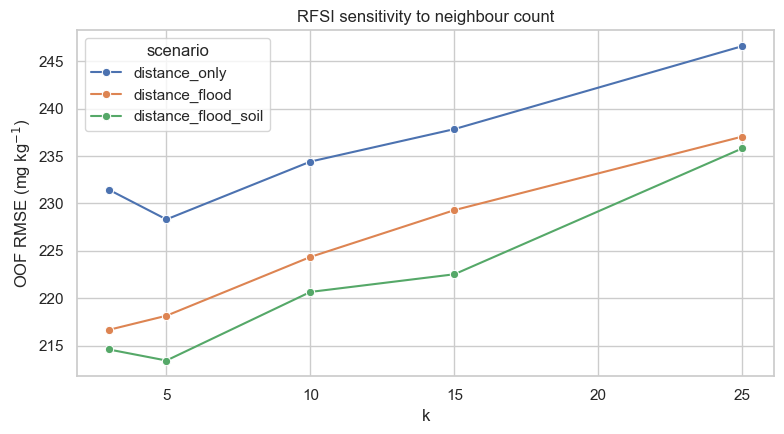

In [20]:
K_VALUES = [3, 5, 10, 15, 25]
k_rows = []

for scenario, columns in SCENARIOS.items():
    for k in K_VALUES:
        print(f"k sensitivity: {scenario}, k={k}")
        result = cross_validate_method(
            meuse, primary_folds, columns, "RFSI", k=k, n_trees=400
        )
        k_rows.append({
            "scenario": scenario,
            "k": k,
            **regression_metrics(result["observed"], result["predicted"]),
        })

k_sensitivity = pd.DataFrame(k_rows)
display(k_sensitivity.round(3))

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.lineplot(data=k_sensitivity, x="k", y="RMSE", hue="scenario", marker="o", ax=ax)
ax.set_ylabel("OOF RMSE (mg kg$^{-1}$)")
ax.set_title("RFSI sensitivity to neighbour count")
plt.tight_layout()
plt.show()

## Repeated 5-fold sensitivity

A single 5-fold split of only 155 observations can be seed-sensitive. Repeating shuffled 5-fold CV checks whether the direction and approximate size of the RFSI effect are stable across partitions. Repetitions are not independent experiments, so their percentile interval is a stability summary rather than a classical confidence interval.

delta_RMSE                         delta_MAE         \
                          mean     std     min     max      mean    std   
scenario                                                                  
distance_flood          -3.038  10.104 -16.125  13.076   -11.506  4.641   
distance_flood_soil      3.113   7.894  -8.180  15.526    -6.588  4.070   
distance_only          -19.259   8.103 -30.492  -8.218   -19.471  4.738   

                                    delta_R2                       
                        min     max     mean    std    min    max  
scenario                                                           
distance_flood      -18.662  -5.100    0.010  0.035 -0.046  0.055  
distance_flood_soil -11.627   1.604   -0.011  0.027 -0.052  0.028  
distance_only       -25.936 -10.807    0.073  0.030  0.031  0.118

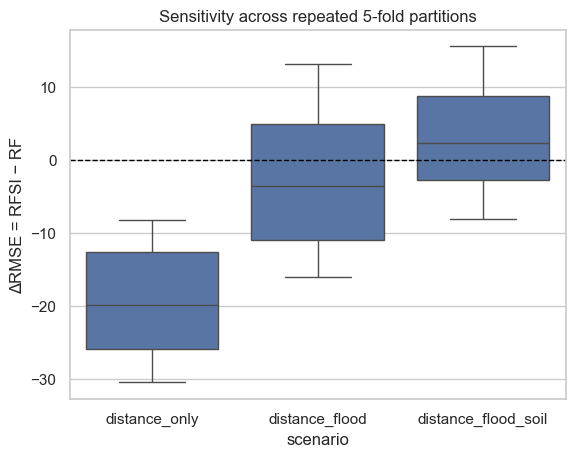

In [21]:
RUN_REPEATED_CV = True
N_REPEATS = 10

repeated_rows = []
if RUN_REPEATED_CV:
    for repeat in range(N_REPEATS):
        folds = make_random_folds(meuse, random_state=RANDOM_STATE + repeat)
        for scenario, columns in SCENARIOS.items():
            repeat_metrics = {}
            for method in ["RF", "RFSI"]:
                result = cross_validate_method(
                    meuse, folds, columns, method, k=K_NEIGHBORS, n_trees=300
                )
                repeat_metrics[method] = regression_metrics(
                    result["observed"], result["predicted"]
                )
            repeated_rows.append({
                "repeat": repeat + 1,
                "scenario": scenario,
                "delta_RMSE": repeat_metrics["RFSI"]["RMSE"] - repeat_metrics["RF"]["RMSE"],
                "delta_MAE": repeat_metrics["RFSI"]["MAE"] - repeat_metrics["RF"]["MAE"],
                "delta_R2": repeat_metrics["RFSI"]["R2"] - repeat_metrics["RF"]["R2"],
            })

    repeated_results = pd.DataFrame(repeated_rows)
    display(repeated_results.groupby("scenario")[["delta_RMSE", "delta_MAE", "delta_R2"]]
            .agg(["mean", "std", "min", "max"]).round(3))
    sns.boxplot(data=repeated_results, x="scenario", y="delta_RMSE")
    plt.axhline(0, color="black", linestyle="--", linewidth=1)
    plt.ylabel("ΔRMSE = RFSI − RF")
    plt.title("Sensitivity across repeated 5-fold partitions")
    plt.show()
else:
    print("Repeated CV skipped. Set RUN_REPEATED_CV=True to run it.")

## Spatially clustered 5-fold validation

Random CV answers: *How well can I interpolate unsampled points located among the remaining sample network?* A spatial-cluster test asks: *How well can I predict a geographically withheld subregion?* These are different operational tasks.

RFSI normally benefits from nearby observed values. In a held-out cluster its nearest reference observations are farther away, so performance may deteriorate sharply. This is not a contradiction; it reveals that interpolation accuracy does not equal spatial extrapolation accuracy.

K-means clusters are a transparent demonstration, not an optimal spatial blocking algorithm.

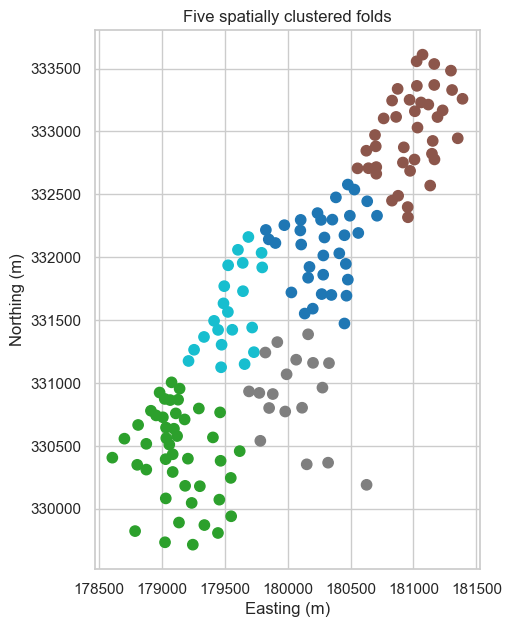

,scenario,method,RMSE,MAE,R2,ME,CCC
0,distance_only,RF,273.511,189.393,0.441,8.197,0.684
1,distance_only,RFSI,332.182,270.833,0.176,141.991,0.408
2,distance_flood,RF,260.068,192.978,0.495,24.611,0.722
3,distance_flood,RFSI,327.758,265.270,0.198,143.926,0.441
4,distance_flood_soil,RF,243.424,178.883,0.557,24.207,0.745
5,distance_flood_soil,RFSI,312.584,254.193,0.270,136.072,0.489


In [22]:
xy = meuse[["x", "y"]].to_numpy(dtype=float)
xy_scaled = (xy - xy.mean(axis=0)) / xy.std(axis=0)
cluster_id = KMeans(n_clusters=5, n_init=50, random_state=RANDOM_STATE).fit_predict(xy_scaled)

spatial_folds = []
all_index = np.arange(len(meuse))
for cluster in np.unique(cluster_id):
    test_index = all_index[cluster_id == cluster]
    train_index = all_index[cluster_id != cluster]
    spatial_folds.append((train_index, test_index))

fig, ax = plt.subplots(figsize=(6, 7))
ax.scatter(meuse["x"], meuse["y"], c=cluster_id, cmap="tab10", s=55)
ax.set_aspect("equal")
ax.set_title("Five spatially clustered folds")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
plt.show()

spatial_rows = []
for scenario, columns in SCENARIOS.items():
    for method in ["RF", "RFSI"]:
        result = cross_validate_method(
            meuse, spatial_folds, columns, method, k=K_NEIGHBORS, n_trees=500
        )
        spatial_rows.append({
            "scenario": scenario,
            "method": method,
            **regression_metrics(result["observed"], result["predicted"]),
        })

spatial_scores = pd.DataFrame(spatial_rows)
display(spatial_scores.round(3))

## Log-target sensitivity

Random Forest does not require a normal target, so a log transform is not mandatory. It changes the loss emphasis: fitting `log1p(zinc)` usually pays relatively more attention to proportional errors and low concentrations, while raw-scale RMSE prioritizes large absolute errors at high concentrations.

If used, fit the model on `log1p(zinc)`, predict on the log scale, and back-transform with `expm1`. A simple inverse transform estimates something closer to a conditional median on the raw scale and can be downward biased for a conditional mean. For that reason, raw-zinc results remain the main answer; a rigorous mean prediction would require a retransformation correction.

In [23]:
def cross_validate_log_target(data, folds, environmental_columns, method, k=K_NEIGHBORS):
    oof = np.full(len(data), np.nan)
    for fold_number, (train_index, test_index) in enumerate(folds, start=1):
        train = data.iloc[train_index].reset_index(drop=True)
        test = data.iloc[test_index].reset_index(drop=True)
        X_train, X_test = fold_feature_tables(train, test, environmental_columns, method, k)
        model = make_rf_pipeline(
            X_train.columns.tolist(), random_state=RANDOM_STATE + fold_number, n_trees=500
        )
        model.fit(X_train, np.log1p(train["zinc"]))
        oof[test_index] = np.expm1(model.predict(X_test))
    return oof


RUN_LOG_SENSITIVITY = True
if RUN_LOG_SENSITIVITY:
    log_rows = []
    for scenario, columns in SCENARIOS.items():
        for method in ["RF", "RFSI"]:
            pred = cross_validate_log_target(meuse, primary_folds, columns, method)
            log_rows.append({
                "scenario": scenario,
                "method": method,
                **regression_metrics(meuse["zinc"], pred),
            })
    display(pd.DataFrame(log_rows).round(3))
else:
    print("Log-target sensitivity skipped. Set RUN_LOG_SENSITIVITY=True to run it.")

,scenario,method,RMSE,MAE,R2,ME,CCC
0,distance_only,RF,259.033,175.360,0.499,-32.190,0.694
1,distance_only,RFSI,249.988,156.071,0.533,-59.362,0.645
2,distance_flood,RF,231.949,160.055,0.598,-31.487,0.760
3,distance_flood,RFSI,236.685,146.729,0.582,-59.075,0.687
4,distance_flood_soil,RF,225.114,154.416,0.621,-32.988,0.766
5,distance_flood_soil,RFSI,232.729,142.804,0.595,-56.499,0.703


## Conclusion after applying additional sensitivity analyses

The sensitivity analyses confirm that the RFSI advantage is robust mainly when environmental predictors are limited. In the distance_only scenario, RFSI outperformed RF in all repeated cross-validation runs, with the strongest performance generally obtained using 3–5 neighbours. Once flood frequency and soil type were added, the RMSE advantage became small and unstable across partitions.

**Spatially clustered validation reversed the result:** RFSI performed substantially worse than RF and showed strong overprediction. Thus, RFSI is useful for interpolation within a well-sampled area but is less reliable for extrapolation into geographically withheld areas. Log-transforming zinc reduced MAE but introduced systematic underprediction and did not improve raw-scale RMSE consistently. 

Overall, RF with relevant environmental covariates appears more robust, while RFSI provides its clearest benefit when covariate information is sparse and nearby observations are available.